<a href="https://colab.research.google.com/github/bhatianidhi/Nidhi_Test_1.chicmicstudios/blob/b1/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv("shopping_trends.csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [ ]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Payment Method',
       'Shipping Type', 'Discount Applied', 'Promo Code Used',
       'Previous Purchases', 'Preferred Payment Method',
       'Frequency of Purchases'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

In [ ]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [ ]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import zscore

numeric_cols = df.select_dtypes(include='number').columns

z_scores = df[numeric_cols].apply(zscore)

df['Global_Outlier'] = (np.abs(z_scores) > 3).any(axis=1)


In [ ]:
df[['Global_Outlier']].value_counts()


,count
Global_Outlier,
False,3900


In [ ]:
z_scores.abs().max().sort_values(ascending=False)


,0
Review Rating,1.745562
Customer ID,1.731607
Age,1.714394
Previous Purchases,1.706334
Purchase Amount (USD),1.698971


In [ ]:
def contextual_outlier_iqr(df, group_col, value_col):
    df = df.copy()
    df['Contextual_Outlier'] = False

    for group in df[group_col].unique():
        subset = df[df[group_col] == group]
        Q1 = subset[value_col].quantile(0.25)
        Q3 = subset[value_col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        idx = subset[(subset[value_col] < lower) |
                     (subset[value_col] > upper)].index

        df.loc[idx, 'Contextual_Outlier'] = True

    return df


In [ ]:
df = contextual_outlier_iqr(df, group_col='Subscription Status', value_col='Purchase Amount (USD)')
df['Contextual_Outlier'].value_counts()


,count
Contextual_Outlier,
False,3900


In [ ]:
def contextual_outlier_iqr(df, group_col, value_col):
    df = df.copy()
    df['Contextual_Outlier'] = False

    for group in df[group_col].unique():
        subset = df[df[group_col] == group]
        Q1 = subset[value_col].quantile(0.25)
        Q3 = subset[value_col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        idx = subset[(subset[value_col] < lower) |
                     (subset[value_col] > upper)].index

        df.loc[idx, 'Contextual_Outlier'] = True

    return df


In [ ]:
for group in df['Subscription Status'].unique():
    subset = df[df['Subscription Status'] == group]
    Q1 = subset['Purchase Amount (USD)'].quantile(0.25)
    Q3 = subset['Purchase Amount (USD)'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    print(f"{group} → Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Lower: {lower}, Upper: {upper}")


Yes → Q1: 39.0, Q3: 80.0, IQR: 41.0, Lower: -22.5, Upper: 141.5
No → Q1: 38.0, Q3: 81.0, IQR: 43.0, Lower: -26.5, Upper: 145.5


In [ ]:
df['Contextual_Outlier'].value_counts()


,count
Contextual_Outlier,
False,3900


In [ ]:
skewness = df[numeric_cols].skew().sort_values(ascending=False)
print(skewness)

Purchase Amount (USD)    0.012702
Review Rating            0.004525
Previous Purchases       0.003121
Customer ID              0.000000
Age                     -0.006380
dtype: float64


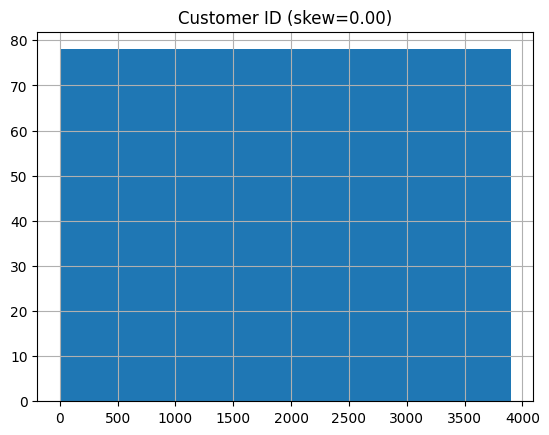

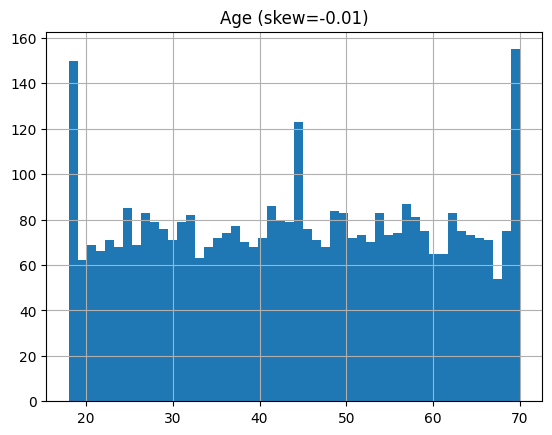

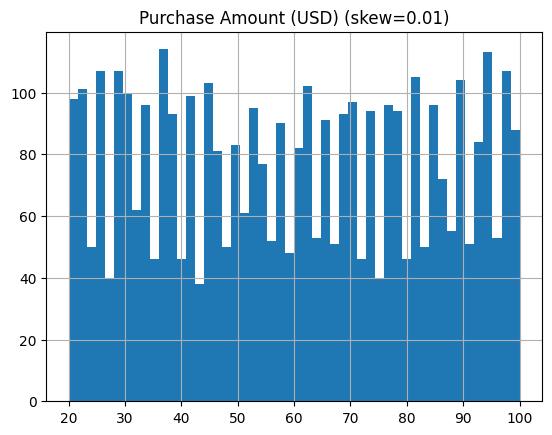

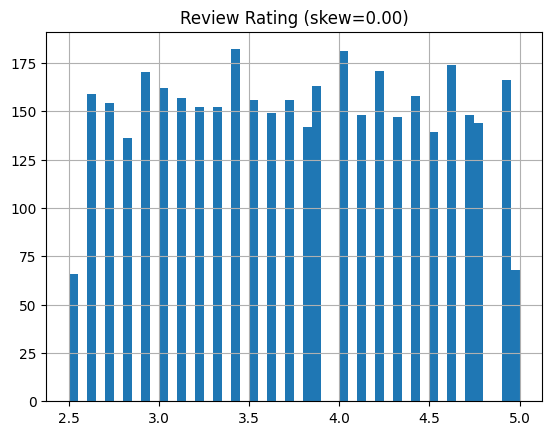

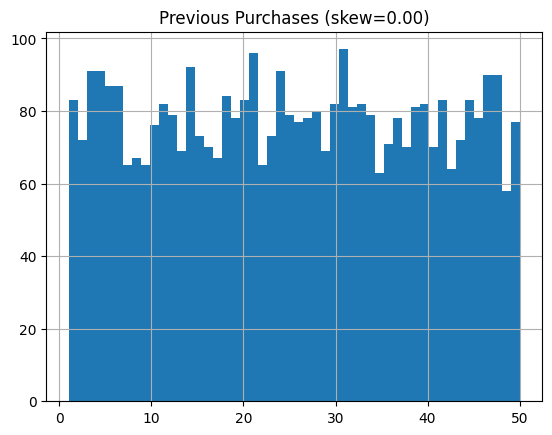

In [ ]:
import matplotlib.pyplot as plt

for col in numeric_cols:
    plt.figure()
    df[col].hist(bins=50)
    plt.title(f'{col} (skew={skewness[col]:.2f})')
    plt.show()


In [ ]:
high_skew = skewness[abs(skewness) > 1]
print(high_skew)


Series([], dtype: float64)


In [ ]:
corr_matrix = df[numeric_cols].corr()
high_corr = (
    corr_matrix.abs()
    .unstack()
    .sort_values(ascending=False)
)

high_corr = high_corr[(high_corr > 0.8) & (high_corr < 1)]


In [ ]:
print(corr_matrix)

                       Customer ID       Age  Purchase Amount (USD)  \
Customer ID               1.000000 -0.004079               0.011048   
Age                      -0.004079  1.000000              -0.010424   
Purchase Amount (USD)     0.011048 -0.010424               1.000000   
Review Rating             0.001343 -0.021949               0.030776   
Previous Purchases       -0.039159  0.040445               0.008063   

                       Review Rating  Previous Purchases  
Customer ID                 0.001343           -0.039159  
Age                        -0.021949            0.040445  
Purchase Amount (USD)       0.030776            0.008063  
Review Rating               1.000000            0.004229  
Previous Purchases          0.004229            1.000000  


In [ ]:
def label_anomaly(row):
    if row['Global_Outlier'] and row['Contextual_Outlier']:
        return 'Global_and_Contextual'
    elif row['Global_Outlier']:
        return 'Global'
    elif row['Contextual_Outlier']:
        return 'Contextual'
    else:
        return 'Normal'

df['Anomaly_Flag'] = df.apply(label_anomaly, axis=1)


In [ ]:
print(df['Anomaly_Flag'].value_counts())



Anomaly_Flag
Normal    3900
Name: count, dtype: int64
